In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


def plot_position_dict(
    data: dict[str, list] | None = None,
    paths: list[list] | None = None,
    star_op: list[list] | None = None,
) -> plt.Figure:
    """Plot Position3DHex positions using their to_euclidean coords.
    Args:
        data:    dict[str, list[Position3DHex]] — each key is a label, plotted as scattered dots.
        paths:   list[list[Position3DHex]] — each inner list plotted with its own color,
                 dots at each position and a line connecting them in list order,
                 with a closing line from last back to first.
        star_op: list[list[Position3DHex]] — each inner list plotted as black crosses.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    n_data  = len(data)  if data  is not None else 0
    n_paths = len(paths) if paths is not None else 0
    n_total = n_data + n_paths

    def rainbow(i: int) -> tuple:
        return cm.rainbow(i / max(n_total - 1, 1))

    color_idx = 0

    if paths is not None:
        for i, positions in enumerate(paths):
            if not positions:
                continue
            color = rainbow(color_idx); color_idx += 1
            xs = [p.to_euclidean()[0] for p in positions]
            ys = [p.to_euclidean()[1] for p in positions]
            ax.plot(xs + [xs[0]], ys + [ys[0]], color=color, linewidth=1.5, zorder=2)
            ax.scatter(xs, ys, color=color, s=60, zorder=3)
            for p, x, y in zip(positions, xs, ys):
                ax.annotate(f"({p.x},{p.y})", (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=7)

    if data is not None:
        for label, positions in data.items():
            color = rainbow(color_idx); color_idx += 1
            xs = [p.to_euclidean()[0] for p in positions]
            ys = [p.to_euclidean()[1] for p in positions]
            ax.scatter(xs, ys, color=color, label=label, s=80, zorder=3)
            for p, x, y in zip(positions, xs, ys):
                ax.annotate(f"({p.x},{p.y})", (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=7)

    if star_op is not None:
        xs = [p.to_euclidean()[0] for p in star_op]
        ys = [p.to_euclidean()[1] for p in star_op]
        ax.scatter(xs, ys, color="black", marker="x", s=80, linewidths=1.5, zorder=4)

    ax.set_aspect("equal")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Position3DHex boundary vertices")
    plt.tight_layout()

In [12]:
d = 15
left_corner = Position3DHex(0,0,0)
triangle_type = "upwards"
dct = ZXPrism.patch_triangle_bdry(d, left_corner, triangle_type)

print(dct)

{'a': [Position3DHex(x=14, y=14, z=0), Position3DHex(x=13, y=13, z=0), Position3DHex(x=12, y=12, z=0), Position3DHex(x=11, y=11, z=0), Position3DHex(x=10, y=10, z=0), Position3DHex(x=9, y=9, z=0), Position3DHex(x=8, y=8, z=0), Position3DHex(x=7, y=7, z=0), Position3DHex(x=6, y=6, z=0), Position3DHex(x=5, y=5, z=0), Position3DHex(x=4, y=4, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=0, y=0, z=0)], 'b': [Position3DHex(x=0, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=4, y=-2, z=0), Position3DHex(x=7, y=-3, z=0), Position3DHex(x=8, y=-4, z=0), Position3DHex(x=11, y=-5, z=0), Position3DHex(x=12, y=-6, z=0), Position3DHex(x=15, y=-7, z=0), Position3DHex(x=16, y=-8, z=0), Position3DHex(x=19, y=-9, z=0), Position3DHex(x=20, y=-10, z=0), Position3DHex(x=23, y=-11, z=0), Position3DHex(x=24, y=-12, z=0), Position3DHex(x=27, y=-13, z=0), Position3DHex(x=28, y=-14, z=0)], 'c': [Position3DHex(x=28, y=-14, z=0), Positio

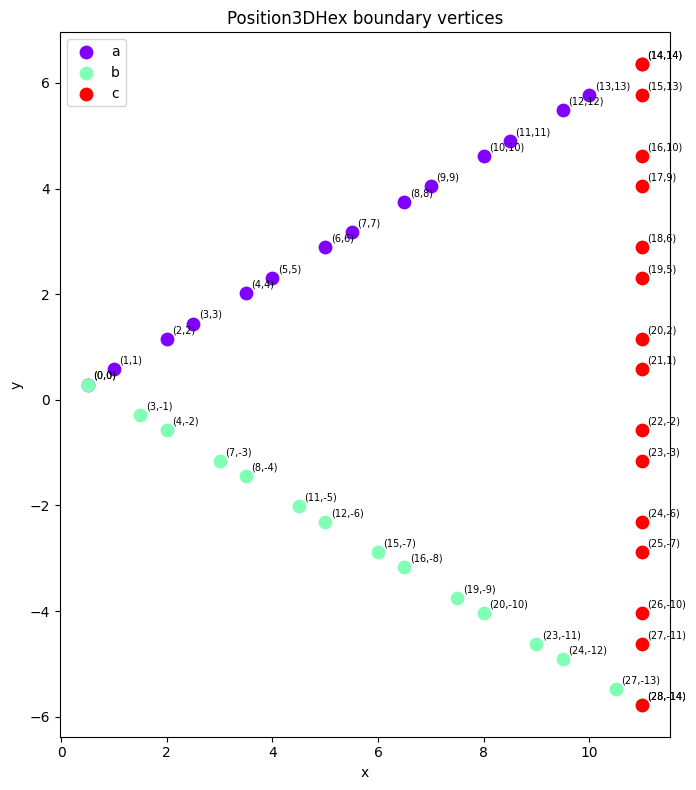

In [13]:
plot_position_dict(dct)

In [14]:
plaqs = ZXPrism.patch_adjacent_bulk_stabilizers(Position3DHex(2,2,0))
print(plaqs)

[[Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=4, y=2, z=0), Position3DHex(x=5, y=1, z=0), Position3DHex(x=4, y=0, z=0), Position3DHex(x=3, y=1, z=0)], [Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=2, y=4, z=0), Position3DHex(x=1, y=5, z=0), Position3DHex(x=0, y=4, z=0), Position3DHex(x=1, y=3, z=0)], [Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=3, z=0), Position3DHex(x=0, y=2, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=1, z=0)]]


True
False
False
True
True
True


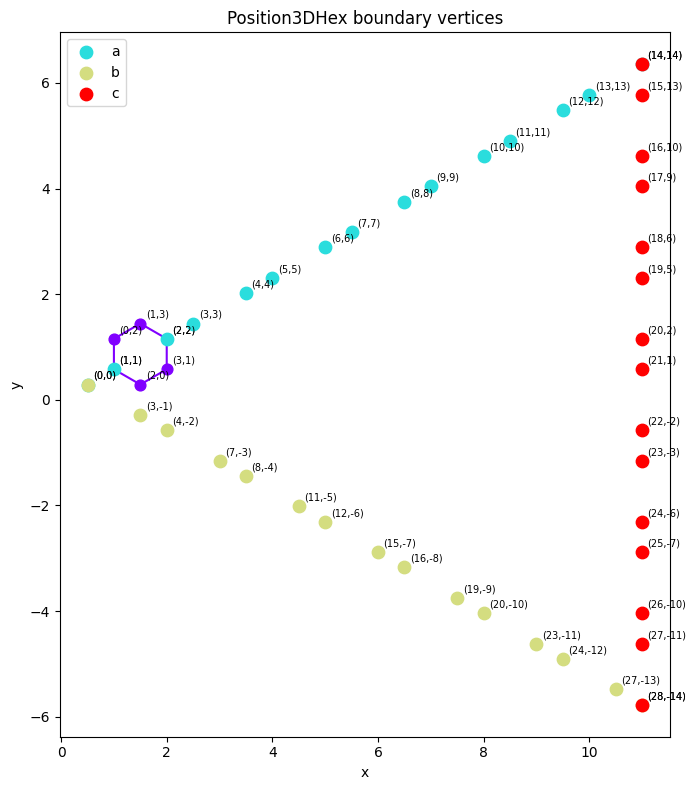

In [15]:
#plot_position_dict(dct, plaqs)
i=2
plot_position_dict(dct, [plaqs[i]])

for pos in plaqs[i]:
    print(ZXPrism.check_within_bdrys(pos, dct, d))

In [16]:
stabilizers = ZXPrism.patch_stabilizers(d, left_corner, [])

number of single type stabilizers: 84.0
len stabilizers 78


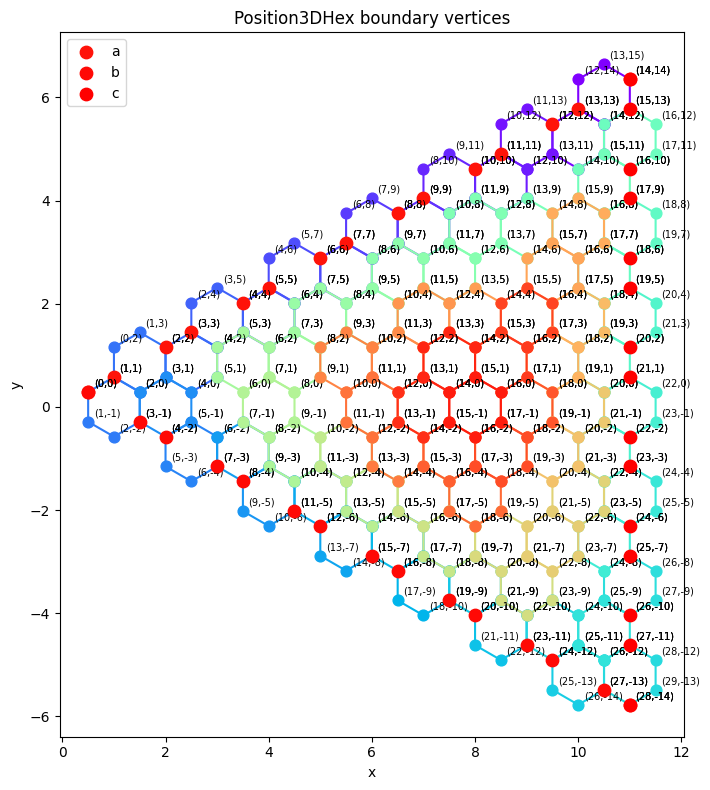

In [17]:
plot_position_dict(dct, stabilizers)
print("number of single type stabilizers:", (3*(d**2-1))/8)
print("len stabilizers", len(stabilizers))

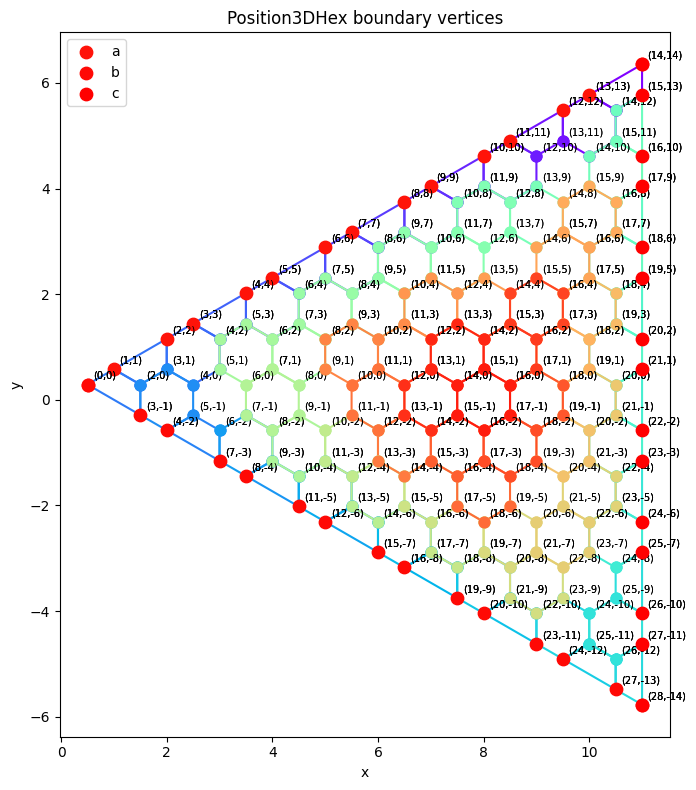

In [18]:
stabilizers = ZXPrism.patch_stabilizers(d, left_corner, ["a", "b", "c"])
plot_position_dict(dct, stabilizers)

In [19]:
star_op = ZXPrism.star_operator_patch(stabilizers, dct)
print(type(star_op[1]))

<class 'tqec.computation.prism.Position3DHex'>


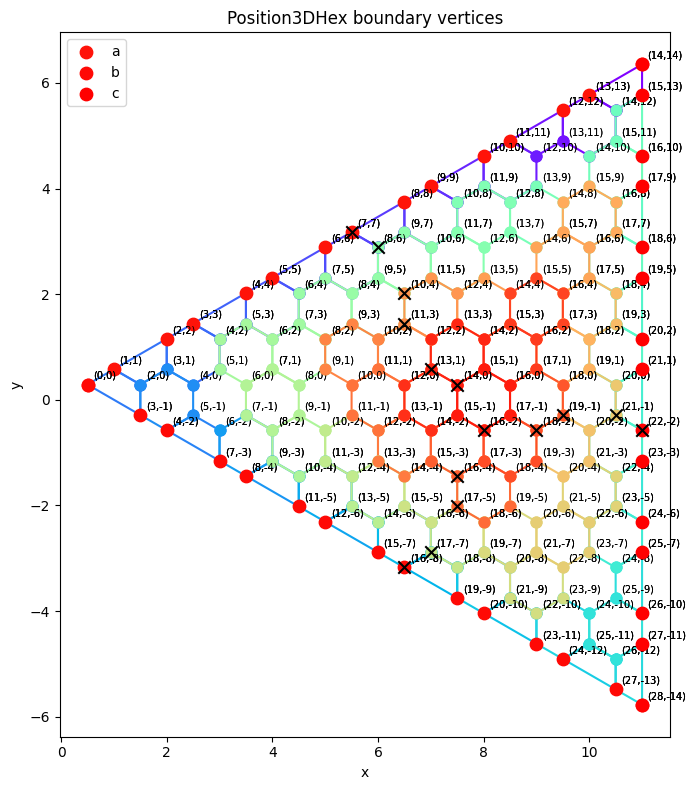

In [20]:
plot_position_dict(dct, stabilizers, star_op)